In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv("Streamli_task.csv")

df.head()

,Age,Gender,AnnualIncome,SpendingScore,MaritalStatus,Purchased
0,25,Male,35000,60,Single,1
1,32,Female,48000,45,Married,0
2,28,Male,52000,75,Single,1
3,45,Female,65000,30,Married,0
4,35,Male,58000,85,Married,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            20 non-null     int64
 1   Gender         20 non-null     str  
 2   AnnualIncome   20 non-null     int64
 3   SpendingScore  20 non-null     int64
 4   MaritalStatus  20 non-null     str  
 5   Purchased      20 non-null     int64
dtypes: int64(4), str(2)
memory usage: 1.3 KB


In [5]:
df.isnull().sum()

Age              0
Gender           0
AnnualIncome     0
SpendingScore    0
MaritalStatus    0
Purchased        0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

Age              0
Gender           0
AnnualIncome     0
SpendingScore    0
MaritalStatus    0
Purchased        0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            20 non-null     int64
 1   Gender         20 non-null     str  
 2   AnnualIncome   20 non-null     int64
 3   SpendingScore  20 non-null     int64
 4   MaritalStatus  20 non-null     str  
 5   Purchased      20 non-null     int64
dtypes: int64(4), str(2)
memory usage: 1.3 KB


In [9]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["MaritalStatus"] = df["MaritalStatus"].map({"Single": 1, "Married": 0})

df.head()

,Age,Gender,AnnualIncome,SpendingScore,MaritalStatus,Purchased
0,25,1,35000,60,1,1
1,32,0,48000,45,0,0
2,28,1,52000,75,1,1
3,45,0,65000,30,0,0
4,35,1,58000,85,0,1


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            20 non-null     int64
 1   Gender         20 non-null     int64
 2   AnnualIncome   20 non-null     int64
 3   SpendingScore  20 non-null     int64
 4   MaritalStatus  20 non-null     int64
 5   Purchased      20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [11]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  Gender  AnnualIncome  SpendingScore  MaritalStatus
0   25       1         35000             60              1
1   32       0         48000             45              0
2   28       1         52000             75              1
3   45       0         65000             30              0
4   35       1         58000             85              0

Target:
0    1
1    0
2    1
3    0
4    1
Name: Purchased, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16, 5)
X_test shape: (4, 5)
y_train shape: (16,)
y_test shape: (4,)


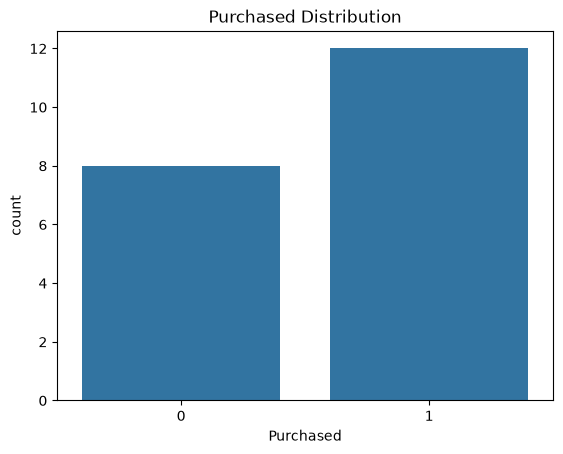

In [13]:
sns.countplot(x="Purchased", data=df)
plt.title("Purchased Distribution")
plt.show()

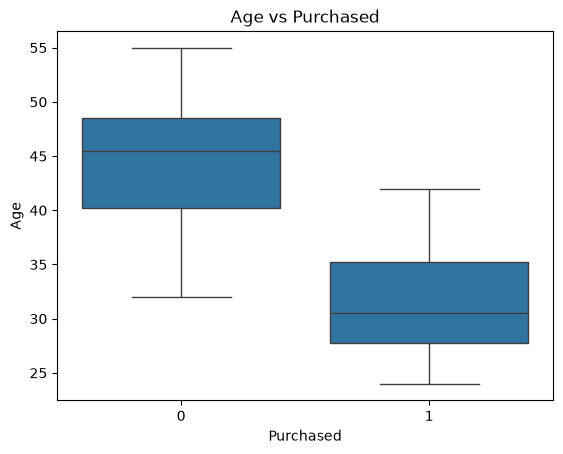

In [14]:
sns.boxplot(x="Purchased", y="Age", data=df)
plt.title("Age vs Purchased")
plt.show()

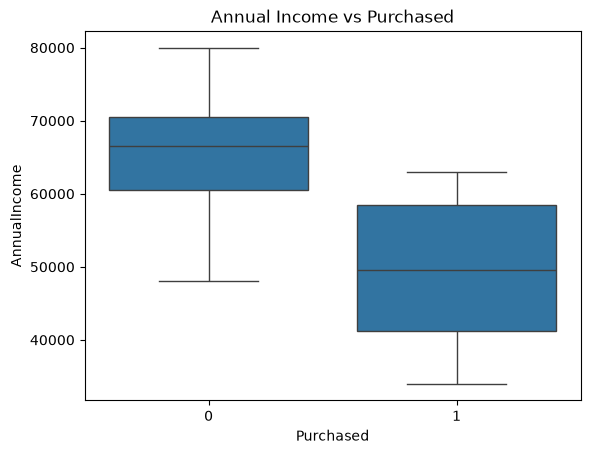

In [15]:

sns.boxplot(x="Purchased", y="AnnualIncome", data=df)
plt.title("Annual Income vs Purchased")
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16, 5)
X_test shape: (4, 5)
y_train shape: (16,)
y_test shape: (4,)


In [17]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:")
print(X_train_scaled)

print("\nX_test_scaled:")
print(X_test_scaled)

X_train_scaled:
[[0.09677419 1.         0.10869565 0.71428571 1.        ]
 [0.16129032 0.         0.17391304 0.64285714 1.        ]
 [0.70967742 0.         0.73913043 0.21428571 0.        ]
 [0.67741935 0.         0.67391304 0.14285714 0.        ]
 [0.29032258 1.         0.43478261 0.82857143 1.        ]
 [0.         1.         0.         0.74285714 1.        ]
 [0.19354839 0.         0.23913043 0.68571429 1.        ]
 [0.12903226 1.         0.39130435 0.78571429 1.        ]
 [0.4516129  0.         0.47826087 0.28571429 0.        ]
 [0.5483871  0.         0.60869565 0.4        0.        ]
 [0.35483871 1.         0.52173913 0.92857143 0.        ]
 [0.38709677 1.         0.56521739 1.         0.        ]
 [0.51612903 0.         0.58695652 0.5        0.        ]
 [0.22580645 1.         0.2826087  0.85714286 1.        ]
 [1.         1.         1.         0.         0.        ]
 [0.83870968 1.         0.82608696 0.07142857 0.        ]]

X_test_scaled:
[[0.03225806 1.         0.02173913 0.57

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000),
 'Naive Bayes': GaussianNB(),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42)}

In [19]:
results = {}

for name, model in models.items():
    print(f"\n{name}")
    
    if name in ["Logistic Regression", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = [acc, pre, rec, f1]

    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1 Score:", f1)

results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1 Score"]
).T

results_df


Logistic Regression
Accuracy: 0.75
Precision: 1.0
Recall: 0.5
F1 Score: 0.6666666666666666

Naive Bayes
Accuracy: 0.75
Precision: 1.0
Recall: 0.5
F1 Score: 0.6666666666666666

Decision Tree
Accuracy: 0.75
Precision: 1.0
Recall: 0.5
F1 Score: 0.6666666666666666

Random Forest
Accuracy: 0.75
Precision: 1.0
Recall: 0.5
F1 Score: 0.6666666666666666


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.75,1.0,0.5,0.666667
Naive Bayes,0.75,1.0,0.5,0.666667
Decision Tree,0.75,1.0,0.5,0.666667
Random Forest,0.75,1.0,0.5,0.666667


In [20]:

best_model_name = results_df["Recall"].idxmax()
print("Best model based on Recall:", best_model_name)
best_model = models[best_model_name]

if best_model_name in ["Logistic Regression", "Naive Bayes"]:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

# Saving the model
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Saving the scaler
if best_model_name in ["Logistic Regression", "Naive Bayes"]:
    with open("scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

Best model based on Recall: Logistic Regression
